# DAU 차트를 봐서는 DAU를 올릴 수 없다 — 유저 세그먼트 분석 실습

DAU 한 줄짜리 그래프로는 신규 유저의 안착도, 헤비 유저의 이탈 징후도, 잠들었던 유저의 부활도
모두 한 점으로 뭉개져 보이지 않습니다. 이 노트북은 유저를 **7개 세그먼트**로 쪼개고,
세그먼트 사이의 **이동(Flow)** 과 비율 지표로 서비스 건강도를 입체적으로 들여다봅니다.

분석은 두 개의 원천 테이블에서 출발합니다.

| 테이블 | 입자 단위 | 역할 |
| :-- | :-- | :-- |
| `user_master` | user_id (유저당 1행) | 유저별 가입(첫 접속) 정보 |
| `user_activity` | user_id × event_date | 유저별 일별 접속 기록 |

- **실습 1.** 두 테이블에서 4개 파생지표(`is_newbie`, `d0_active`, `active_day_count`, `last_active_date`)를 만들고, 정해진 기준에 따라 7개 세그먼트로 분류합니다.
- **실습 2.** 어제·오늘 두 시점의 세그먼트를 한 행에 담아, 세그먼트 변화를 추적할 수 있는 마트를 만듭니다.
- **실습 3.** 그 마트를 분포(Stock) · 전이 행렬(Flow) · 비율 지표(HURR/CURR/Heavy Loss/Light Loss/Reactivation) 세 각도로 분석합니다.
- **실습 4.** 마트를 여러 날 적재해, 30일 전 heavy 유저가 오늘 어디로 흩어졌는지 N일 변화를 추적합니다.

쿼리는 모두 **DuckDB**로 예시 CSV에 직접 실행합니다.

## 0. 준비

아래 셀은 의존성을 설치합니다. 데이터가 없다면 먼저 터미널에서
`python generate_data.py` 를 실행해 예시 데이터를 만들어 주세요
(`data/user_master.csv`, `data/user_activity.csv`).

In [2]:
# 의존성 설치 (이미 설치돼 있으면 빠르게 넘어갑니다)
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# DuckDB 인메모리 연결 하나를 만들어 노트북 전체에서 재사용합니다.
con = duckdb.connect()

SEG_ORDER = ["new", "heavy_active", "light_active",
             "heavy_inactive", "light_inactive", "risk", "dormant"]
TARGET = "2026-05-20"   # 분석 기준일(오늘)
# [내 데이터 적용] 분석 기준일을 내 날짜로 바꿉니다. 단, 아래 쿼리들에는 '2026-05-20'이 문자열로 박혀 있어
#   기준일을 바꾸려면 각 쿼리의 날짜도 함께 바꿔야 합니다(실습 4처럼 .replace로 일괄 치환해도 됩니다).

## 실습용 데이터 준비

먼저 두 원천 테이블을 살펴봅니다. `user_master` 는 유저당 한 줄(가입일),
`user_activity` 는 접속한 날마다 한 줄씩 쌓이는 로그입니다.

In [4]:
# [내 데이터 적용] 내 서비스의 두 테이블로 바꿉니다 —
#   user_master(user_id, first_active_date), user_activity(user_id, event_date).
master = con.execute("SELECT * FROM read_csv_auto('data/user_master.csv')").df()
activity = con.execute("SELECT * FROM read_csv_auto('data/user_activity.csv')").df()
print("user_master  :", master.shape)
print("user_activity:", activity.shape)
master.head()

user_master  : (200, 2)
user_activity: (4755, 2)


,user_id,first_active_date
0,user_001,2026-05-20
1,user_002,2026-05-20
2,user_003,2026-05-20
3,user_004,2026-05-20
4,user_005,2026-05-20


In [5]:
activity.head()

,user_id,event_date
0,user_032,2026-01-27
1,user_144,2026-01-27
2,user_144,2026-01-28
3,user_123,2026-01-29
4,user_144,2026-01-29


## 실습 1. 4개의 파생지표로 7개 세그먼트 분류하기

유저 한 명 한 명을 활동성을 요약하는 4개 파생지표로 환원한 뒤, 그 지표를 기준으로 7개
세그먼트 중 하나로 분류합니다. 지표 만들기와 분류를 두 단계로 나눠 진행합니다.

이제 두 테이블을 `LEFT JOIN` 한 뒤 유저 단위로 집계해, 세그먼트 분류의 토대가 되는
**4개 파생지표**를 만듭니다. 결과는 `user_metrics` 테이블에 담아 두고, 다음 단계의 분류
쿼리가 이 테이블을 입력으로 씁니다.

- `is_newbie` — 오늘이 첫 접속일인가
- `d0_active` — 오늘 접속했는가
- `active_day_count` — 최근 7일 중 며칠 접속했는가
- `last_active_date` — 가장 최근 접속일은

> 가입(첫 접속) 당일은 반드시 활동이 한 줄 찍히므로(가입 = 첫 접속), 활동이 0행인 유저는
> 없습니다. 덕분에 `count_if`/`bool_or` 가 NULL 이 될 일이 없어 집계를 깔끔하게 쓸 수 있습니다.

In [6]:
# 1) 4개 파생지표 만들기 — user_master 와 user_activity 를 LEFT JOIN 해 유저 단위로 집계
# [내 데이터 적용] '최근 활동' 윈도우는 아래 SQL의 INTERVAL 6 DAY(=기준일 포함 7일)입니다.
#   서비스 사용 주기에 맞춰 길이를 조정합니다(예: 주 1회 쓰는 서비스면 더 길게).
metrics_query = """
CREATE OR REPLACE TABLE user_metrics AS
SELECT
  m.user_id,
  -- 1. 오늘 가입한 유저 여부
  (m.first_active_date = DATE '2026-05-20') AS is_newbie,
  -- 2. 오늘 접속 여부
  bool_or(a.event_date = DATE '2026-05-20') AS d0_active,
  -- 3. 최근 7일(기준일 포함) 접속 일수
  count_if(a.event_date BETWEEN DATE '2026-05-20' - INTERVAL 6 DAY
                            AND DATE '2026-05-20') AS active_day_count,
  -- 4. 마지막 활동일 (가입 당일 활동이 보장되므로 항상 존재)
  max(CASE WHEN a.event_date <= DATE '2026-05-20' THEN a.event_date END) AS last_active_date
FROM read_csv_auto('data/user_master.csv') m
LEFT JOIN read_csv_auto('data/user_activity.csv') a USING (user_id)
GROUP BY m.user_id, m.first_active_date
"""
con.execute(metrics_query)
con.execute("SELECT * FROM user_metrics ORDER BY user_id").df().head()

,user_id,is_newbie,d0_active,active_day_count,last_active_date
0,user_001,True,True,1.0,2026-05-20
1,user_002,True,True,1.0,2026-05-20
2,user_003,True,True,1.0,2026-05-20
3,user_004,True,True,1.0,2026-05-20
4,user_005,True,True,1.0,2026-05-20


이제 위에서 만든 `user_metrics` 의 4개 지표를 **정해진 기준**에 따라 `CASE WHEN` 한 단계로
7개 세그먼트로 분류합니다. 분류 기준은 다음과 같습니다.

| 세그먼트 | 분류 기준 |
| :-- | :-- |
| `new` | 오늘 가입 (`is_newbie`) |
| `heavy_active` | 오늘 접속 & 최근 7일 5일 이상 |
| `light_active` | 오늘 접속 & 최근 7일 1~4일 |
| `heavy_inactive` | 오늘 미접속 & 최근 7일 5일 이상 |
| `light_inactive` | 오늘 미접속 & 최근 7일 1~4일 |
| `risk` | 최근 7일 0일 & 마지막 접속 7~30일 전 |
| `dormant` | 최근 7일 0일 & 마지막 접속 30일 초과 |

> `active_day_count = 0` 은 최근 7일 접속이 없다는 뜻이므로, risk·dormant 분기에는
> `d0_active`(오늘 접속) 조건을 따로 두지 않았습니다.

In [7]:
# 2) 정해진 기준에 따라 7개 세그먼트로 분류 — 위에서 만든 user_metrics 를 입력으로 사용
# [내 데이터 적용] 여기가 세그먼트 정의입니다. heavy 컷(active_day_count >= 5), risk/dormant 경계
#   (마지막 접속 7~30일 / 30일 초과) 같은 임계값을 내 서비스 기준에 맞게 바꿉니다.
classify_query = """
SELECT
  user_id,
  is_newbie,
  d0_active,
  active_day_count,
  last_active_date,
  CASE
    WHEN is_newbie                                                        THEN 'new'
    WHEN d0_active     AND active_day_count >= 5                          THEN 'heavy_active'
    WHEN d0_active     AND active_day_count BETWEEN 1 AND 4               THEN 'light_active'
    WHEN NOT d0_active AND active_day_count >= 5                          THEN 'heavy_inactive'
    WHEN NOT d0_active AND active_day_count BETWEEN 1 AND 4               THEN 'light_inactive'
    -- active_day_count = 0 이면 최근 7일 접속이 없다는 뜻이므로 d0_active 조건은 불필요하다.
    WHEN active_day_count = 0
         AND last_active_date BETWEEN DATE '2026-05-20' - INTERVAL 30 DAY
                                  AND DATE '2026-05-20' - INTERVAL 6 DAY THEN 'risk'
    WHEN active_day_count = 0
         AND last_active_date <  DATE '2026-05-20' - INTERVAL 30 DAY     THEN 'dormant'
  END AS user_seg
FROM user_metrics
ORDER BY user_id;
"""
seg = con.execute(classify_query).df()
print(seg["user_seg"].value_counts().reindex(SEG_ORDER))

user_seg
new               10
heavy_active      30
light_active      30
heavy_inactive     9
light_inactive    48
risk              53
dormant           20
Name: count, dtype: int64


7개 세그먼트가 모두 등장하도록 각 세그먼트에서 한 명씩 뽑아 보면, 4개 지표가
어떻게 하나의 세그먼트로 압축되는지 한눈에 들어옵니다.

In [8]:
# 각 세그먼트의 대표 유저를 한 명씩 발췌
sample = seg.groupby("user_seg").first().reindex(SEG_ORDER).reset_index()
sample[["user_seg", "user_id", "is_newbie", "d0_active", "active_day_count", "last_active_date"]]

,user_seg,user_id,is_newbie,d0_active,active_day_count,last_active_date
0,new,user_001,True,True,1.0,2026-05-20
1,heavy_active,user_017,False,True,6.0,2026-05-20
2,light_active,user_016,False,True,3.0,2026-05-20
3,heavy_inactive,user_022,False,False,5.0,2026-05-19
4,light_inactive,user_011,False,False,1.0,2026-05-16
5,risk,user_021,False,False,0.0,2026-04-22
6,dormant,user_026,False,False,0.0,2026-04-16


## 실습 2. 세그먼트 변화 추적 가능한 데이터 마트 만들기

한 시점의 분포(Stock)만으로는 "heavy가 어제와 같은 30명이라도, 그대로 남은 30명인지
빠진 자리를 다른 유저가 채운 건지"를 구별할 수 없습니다. 그 변화(Flow)를 보려면
**어제와 오늘 두 시점의 세그먼트를 한 행에 나란히 담은 마트**가 필요합니다.

아래 쿼리는 4개 지표를 오늘·어제 두 시점으로 계산해 `user_seg`(오늘)와
`user_seg_from`(어제)을 한 행에 담고, 그 결과를 `mart_user_segment` 테이블로 적재합니다.

적재한 뒤에는 `head()` 로 전체를 훑는 대신, 어제→오늘 변화가 뚜렷한 유저 몇 명을 골라
`user_seg_from`(어제) → `user_seg`(오늘) 이 어떻게 달라지는지 확인해 보겠습니다.

In [9]:
# [내 데이터 적용] 실습 1의 분류 기준을 '오늘·어제' 두 시점으로 적용한 마트입니다.
#   실습 1에서 임계값(heavy 컷·경계일)을 바꿨다면 아래 두 CASE 블록에도 똑같이 반영해야 합니다.
build_mart_query = """
-- 유저 세그먼트 마트 생성 (mart_user_segment)
--
-- 두 원천 CSV에서 4개 파생지표를 '오늘'과 '어제' 두 시점으로 계산하고,
-- 각 시점을 7개 세그먼트로 분류해 한 행에 user_seg(오늘) / user_seg_from(어제)으로 담는다.
-- 기준일(target_date)은 2026-05-20.
--
-- 가입 당일은 반드시 활동이 찍히므로(가입 = 첫 접속) 활동 0행 유저는 없다. 단, 오늘 막
-- 가입한 신규는 '어제' 시점엔 없으므로 last_active_date_from 이 NULL → user_seg_from 도 NULL.

CREATE OR REPLACE TABLE mart_user_segment AS
WITH metrics AS (
  SELECT
    m.user_id,

    -- [오늘 시점 지표]
    (m.first_active_date = DATE '2026-05-20') AS is_newbie,
    bool_or(a.event_date = DATE '2026-05-20') AS d0_active,
    count_if(a.event_date BETWEEN DATE '2026-05-20' - INTERVAL 6 DAY
                              AND DATE '2026-05-20') AS active_day_count,
    max(CASE WHEN a.event_date <= DATE '2026-05-20' THEN a.event_date END) AS last_active_date,

    -- [어제 시점 지표] (윈도우를 하루씩 미룬다)
    (m.first_active_date = DATE '2026-05-20' - INTERVAL 1 DAY) AS is_newbie_from,
    bool_or(a.event_date = DATE '2026-05-20' - INTERVAL 1 DAY) AS d0_active_from,
    count_if(a.event_date BETWEEN DATE '2026-05-20' - INTERVAL 7 DAY
                              AND DATE '2026-05-20' - INTERVAL 1 DAY) AS active_day_count_from,
    -- 어제까지의 마지막 활동일. 오늘 막 가입한 신규는 어제 활동이 없어 NULL → user_seg_from 도 NULL.
    max(CASE WHEN a.event_date <= DATE '2026-05-20' - INTERVAL 1 DAY THEN a.event_date END) AS last_active_date_from
  FROM read_csv_auto('data/user_master.csv') m
  LEFT JOIN read_csv_auto('data/user_activity.csv') a USING (user_id)
  GROUP BY m.user_id, m.first_active_date
)
SELECT
  DATE '2026-05-20' AS target_date,
  user_id,

  -- [어제 시점 분류]
  CASE
    WHEN is_newbie_from                                                          THEN 'new'
    WHEN d0_active_from     AND active_day_count_from >= 5                        THEN 'heavy_active'
    WHEN d0_active_from     AND active_day_count_from BETWEEN 1 AND 4             THEN 'light_active'
    WHEN NOT d0_active_from AND active_day_count_from >= 5                        THEN 'heavy_inactive'
    WHEN NOT d0_active_from AND active_day_count_from BETWEEN 1 AND 4             THEN 'light_inactive'
    WHEN active_day_count_from = 0
         AND last_active_date_from BETWEEN DATE '2026-05-20' - INTERVAL 31 DAY
                                       AND DATE '2026-05-20' - INTERVAL 7 DAY    THEN 'risk'
    WHEN active_day_count_from = 0
         AND last_active_date_from <  DATE '2026-05-20' - INTERVAL 31 DAY        THEN 'dormant'
  END AS user_seg_from,

  -- [오늘 시점 분류]
  CASE
    WHEN is_newbie                                                          THEN 'new'
    WHEN d0_active     AND active_day_count >= 5                            THEN 'heavy_active'
    WHEN d0_active     AND active_day_count BETWEEN 1 AND 4                 THEN 'light_active'
    WHEN NOT d0_active AND active_day_count >= 5                            THEN 'heavy_inactive'
    WHEN NOT d0_active AND active_day_count BETWEEN 1 AND 4                 THEN 'light_inactive'
    WHEN active_day_count = 0
         AND last_active_date BETWEEN DATE '2026-05-20' - INTERVAL 30 DAY
                                  AND DATE '2026-05-20' - INTERVAL 6 DAY   THEN 'risk'
    WHEN active_day_count = 0
         AND last_active_date <  DATE '2026-05-20' - INTERVAL 30 DAY       THEN 'dormant'
  END AS user_seg
FROM metrics
ORDER BY user_id;
"""
con.execute(build_mart_query)
mart = con.execute("SELECT * FROM mart_user_segment ORDER BY user_id").df()
print("mart rows:", len(mart))

# 어제(user_seg_from) → 오늘(user_seg) 변화가 뚜렷한 유저 몇 명만 골라 확인
watch = ["user_015", "user_017", "user_022", "user_028", "user_048"]
mart[mart["user_id"].isin(watch)][["user_id", "user_seg_from", "user_seg"]]

mart rows: 200


,user_id,user_seg_from,user_seg
14,user_015,light_active,light_inactive
16,user_017,heavy_inactive,heavy_active
21,user_022,heavy_active,heavy_inactive
27,user_028,light_inactive,light_active
47,user_048,heavy_inactive,light_inactive


## 실습 3. Stock과 Flow 분석하기

이제 적재한 마트를 두 각도로 분석합니다 — 한 시점의 **분포(Stock)** 와 시점 간 **이동(Flow)**,
그리고 그 이동을 요약한 **비율 지표(KPI)** 입니다.

### Stock — 일별 세그먼트 분포

단순한 `GROUP BY` 한 번이면 한 시점의 분포가 나옵니다.

,user_seg,users
0,new,10
1,heavy_active,30
2,light_active,30
3,heavy_inactive,9
4,light_inactive,48
5,risk,53
6,dormant,20


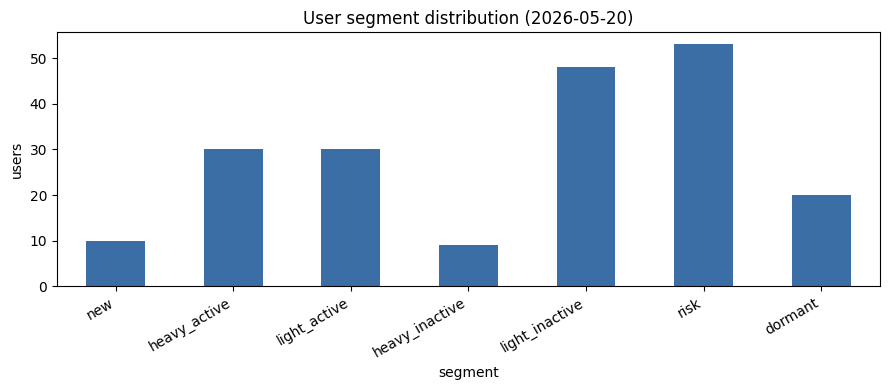

In [10]:
query = """
-- 일별 세그먼트 분포 (Stock)
-- build_mart.sql 로 mart_user_segment 를 먼저 만들어 두어야 한다.

SELECT
  user_seg,
  count(*) AS users
FROM mart_user_segment
WHERE target_date = DATE '2026-05-20'
GROUP BY user_seg
ORDER BY array_position(
  ['new', 'heavy_active', 'light_active', 'heavy_inactive', 'light_inactive', 'risk', 'dormant'],
  user_seg);
"""
dist = con.execute(query).df()
display(dist)

ax = (dist.set_index("user_seg").reindex(SEG_ORDER)["users"]
        .plot.bar(figsize=(9, 4), color="#3b6ea5"))
ax.set_title("User segment distribution (2026-05-20)")
ax.set_xlabel("segment"); ax.set_ylabel("users")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

### Flow — 세그먼트 전이 행렬

어제(`user_seg_from`)를 행, 오늘(`user_seg`)을 열로 펼치면 전이 행렬이 됩니다.
대각선은 그대로 유지된 유저, 대각선 위쪽(오른쪽)은 활동성이 떨어진 유저,
아래쪽(왼쪽)은 활동성이 높아진 유저입니다.

user_seg,heavy_active,light_active,heavy_inactive,light_inactive,risk,dormant
user_seg_from,,,,,,
heavy_active,21,0,9,1,0,0
light_active,2,8,0,16,0,0
heavy_inactive,6,0,0,2,0,0
light_inactive,1,21,0,29,4,0
risk,0,1,0,0,49,1
dormant,0,0,0,0,0,19


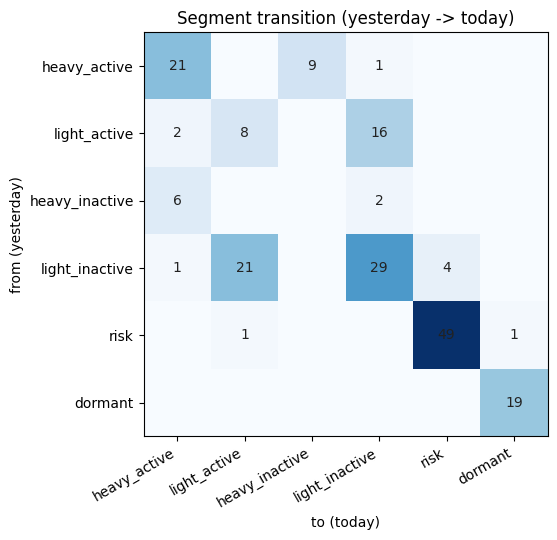

In [11]:
query = """
-- 세그먼트 전이 (Flow): 어제(user_seg_from) -> 오늘(user_seg)
-- build_mart.sql 로 mart_user_segment 를 먼저 만들어 두어야 한다.

SELECT
  user_seg_from,
  user_seg,
  count(*) AS users
FROM mart_user_segment
WHERE target_date = DATE '2026-05-20'
  AND user_seg_from IS NOT NULL   -- 오늘 처음 가입한 신규(어제 NULL)는 별도 분석
  AND user_seg_from <> 'new'      -- 어제 막 가입한 신규도 전이 분석에서는 제외
GROUP BY user_seg_from, user_seg
ORDER BY user_seg_from, user_seg;
"""
trans = con.execute(query).df()

order = ["heavy_active", "light_active", "heavy_inactive", "light_inactive", "risk", "dormant"]
pivot = (trans.pivot(index="user_seg_from", columns="user_seg", values="users")
              .reindex(index=order, columns=order))
display(pivot.fillna(0).astype(int))

m = pivot.values.astype(float)
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.imshow(np.nan_to_num(m), cmap="Blues")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
ax.set_xlabel("to (today)"); ax.set_ylabel("from (yesterday)")
for i in range(len(order)):
    for j in range(len(order)):
        v = m[i, j]
        if not np.isnan(v):
            ax.text(j, i, int(v), ha="center", va="center", color="#222")
ax.set_title("Segment transition (yesterday -> today)")
plt.tight_layout(); plt.show()

### 비율 지표 (KPI)

전이 행렬에서 의미 있는 비율을 뽑으면 그대로 KPI가 됩니다.
`heavy = {heavy_active, heavy_inactive}`, `light = {light_active, light_inactive}` 로 묶었습니다.

- **HURR** — heavy 유지율 · **CURR** — heavy+light(핵심 활동층) 유지율
- **Heavy Loss** — heavy → light 강등 · **Light Loss** — light → risk 이탈
- **Reactivation** — risk → light 복귀

In [12]:
query = """
-- 세그먼트 전이 기반 비율 지표 5종
--   HURR        : heavy(활성+비활성)를 유지하는 비율
--   CURR        : heavy+light(핵심 활동 유저층)를 유지하는 비율
--   Heavy Loss  : heavy 유저가 light 로 떨어진 비율
--   Light Loss  : light 유저가 위험 구간(risk)으로 이탈한 비율
--   Reactivation: 위험(risk) 유저가 다시 light 로 돌아온 비율
--
-- heavy = {heavy_active, heavy_inactive}, light = {light_active, light_inactive}
-- 0 으로 나누는 것을 막기 위해 분모를 nullif(..., 0) 으로 감싼다.

SELECT
  round(count_if(user_seg_from IN ('heavy_active', 'heavy_inactive')
                 AND user_seg  IN ('heavy_active', 'heavy_inactive'))
        / nullif(count_if(user_seg_from IN ('heavy_active', 'heavy_inactive')), 0) * 100, 1) AS hurr_pct,

  round(count_if(user_seg_from IN ('heavy_active', 'heavy_inactive', 'light_active', 'light_inactive')
                 AND user_seg  IN ('heavy_active', 'heavy_inactive', 'light_active', 'light_inactive'))
        / nullif(count_if(user_seg_from IN ('heavy_active', 'heavy_inactive', 'light_active', 'light_inactive')), 0) * 100, 1) AS curr_pct,

  round(count_if(user_seg_from IN ('heavy_active', 'heavy_inactive')
                 AND user_seg  IN ('light_active', 'light_inactive'))
        / nullif(count_if(user_seg_from IN ('heavy_active', 'heavy_inactive')), 0) * 100, 1) AS heavy_loss_pct,

  round(count_if(user_seg_from IN ('light_active', 'light_inactive') AND user_seg = 'risk')
        / nullif(count_if(user_seg_from IN ('light_active', 'light_inactive')), 0) * 100, 1) AS light_loss_pct,

  round(count_if(user_seg_from = 'risk' AND user_seg IN ('light_active', 'light_inactive'))
        / nullif(count_if(user_seg_from = 'risk'), 0) * 100, 1) AS reactivation_pct
FROM mart_user_segment
WHERE target_date = DATE '2026-05-20';
"""
kpi = con.execute(query).df()
kpi.T.rename(columns={0: "pct"})

,pct
hurr_pct,92.3
curr_pct,96.7
heavy_loss_pct,7.7
light_loss_pct,4.9
reactivation_pct,2.0


## 실습 4. N일 후 세그먼트 변화 추적

1일 단위 변화는 폭이 작아 패턴이 잘 안 보입니다(어제 heavy가 오늘도 heavy일 확률이 높으니까요).
시간 축을 길게 잡아 **30일 전 heavy 유저가 오늘 어디에 있는지** 보면 훨씬 또렷한 그림이 나옵니다.

이를 위해 앞서 만든 마트 쿼리를 **기준일만 바꿔 가며 여러 날 적재**합니다.
운영 환경에서 마트가 매일 쌓이는 것을 그대로 흉내 내는 셈입니다.

In [13]:
# 실습 2의 마트 쿼리를 기준일만 바꿔 2026-04-20 ~ 2026-05-20 (31일) 적재한다.
# [내 데이터 적용] 적재할 일수(periods=31)를 N일 추적 구간에 맞게 늘립니다(예: 60·90일 추적이면 더 길게).
# (실습 2에서 하루치만 만들었던 mart_user_segment 를 여러 날치로 다시 채운다.)
con.execute("DROP TABLE IF EXISTS mart_user_segment")
for i, t in enumerate(pd.date_range(end=TARGET, periods=31)):
    ts = t.date().isoformat()
    q = build_mart_query.replace("2026-05-20", ts)
    if i > 0:
        q = q.replace("CREATE OR REPLACE TABLE mart_user_segment AS",
                      "INSERT INTO mart_user_segment BY NAME")
    con.execute(q)

print(con.execute(
    "SELECT count(DISTINCT target_date) AS n_days, count(*) AS n_rows FROM mart_user_segment"
).df())

   n_days  n_rows
0      31    6200


이제 두 시점(30일 전 · 오늘)을 `user_id` 로 self-join 하면, 30일 전 **heavy**(heavy_active +
heavy_inactive) 유저가 오늘 어느 세그먼트로 흩어졌는지가 한 표로 나옵니다.

,seg_30days_ago,seg_today,users,pct
0,heavy_all,heavy_active,24,51.1
1,heavy_all,risk,9,19.1
2,heavy_all,light_inactive,6,12.8
3,heavy_all,light_active,6,12.8
4,heavy_all,heavy_inactive,2,4.3


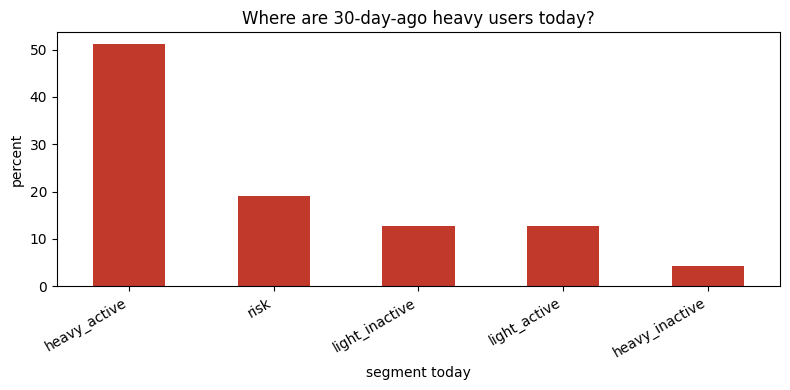

In [14]:
# 30일 전 heavy(=heavy_active + heavy_inactive)를 'heavy_all' 하나로 묶어 오늘 분포를 본다
# [내 데이터 적용] 추적 간격(아래 INTERVAL 30 DAY)과 추적 대상(heavy)을 바꿔 다른 코호트의 N일 변화를 봅니다
#   — 간격을 7·14·60·90으로, 또는 past.user_seg 를 'new'로 바꾸면 신규 유저의 N일 안착(Activation)을 봅니다.
heavy = "('heavy_active', 'heavy_inactive')"
query = f"""
-- N일 후 세그먼트 변화 추적: 30일 전 heavy 였던 유저가 오늘은 어디에 있는가
-- heavy_active 와 heavy_inactive 를 'heavy_all' 로 묶고, 두 시점을 user_id 로 self-join 한다.
-- (past.user_seg 를 'new' 로 바꾸면 신규 유저의 N일 안착 패턴을 볼 수 있다.)

SELECT
  'heavy_all' AS seg_30days_ago,
  curr.user_seg AS seg_today,
  count(*) AS users,
  round(count(*) / sum(count(*)) OVER () * 100, 1) AS pct
FROM mart_user_segment AS past
LEFT JOIN mart_user_segment AS curr
  ON past.user_id = curr.user_id
 AND curr.target_date = DATE '2026-05-20'
WHERE past.target_date = DATE '2026-05-20' - INTERVAL 30 DAY
  AND past.user_seg IN {heavy}
GROUP BY curr.user_seg
ORDER BY users DESC;
"""
nday = con.execute(query).df()
display(nday)

ax = nday.set_index("seg_today")["pct"].plot.bar(figsize=(8, 4), color="#c0392b")
ax.set_title("Where are 30-day-ago heavy users today?")
ax.set_xlabel("segment today"); ax.set_ylabel("percent")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

30일 전 heavy 유저의 절반 가까이가 다른 세그먼트로 흩어졌습니다. 이걸 **같은 HURR 기준**으로
1일 변화와 나란히 놓고 비교해 보겠습니다 — 둘 다 *heavy(heavy_active + heavy_inactive) 유지율*입니다.

In [15]:
# 같은 'heavy 유지율(HURR)' 을 1일 / 30일 두 시간 축으로 비교
hurr_compare = con.execute(f"""
WITH one_day AS (    -- 어제 heavy -> 오늘 heavy
  SELECT round(count_if(user_seg_from IN {heavy} AND user_seg IN {heavy})
               / nullif(count_if(user_seg_from IN {heavy}), 0) * 100, 1) AS hurr_pct
  FROM mart_user_segment
  WHERE target_date = DATE '2026-05-20'
),
thirty_day AS (      -- 30일 전 heavy -> 오늘 heavy
  SELECT round(count_if(curr.user_seg IN {heavy})
               / nullif(count(*), 0) * 100, 1) AS hurr_pct
  FROM mart_user_segment AS past
  LEFT JOIN mart_user_segment AS curr
    ON past.user_id = curr.user_id AND curr.target_date = DATE '2026-05-20'
  WHERE past.target_date = DATE '2026-05-20' - INTERVAL 30 DAY
    AND past.user_seg IN {heavy}
)
SELECT '1일 (어제 → 오늘)'     AS horizon, hurr_pct FROM one_day
UNION ALL
SELECT '30일 (30일 전 → 오늘)', hurr_pct FROM thirty_day
""").df()
hurr_compare

,horizon,hurr_pct
0,1일 (어제 → 오늘),92.3
1,30일 (30일 전 → 오늘),55.3


1일 기준으로는 heavy 유저의 **92.3%**가 다음 날에도 heavy로 남지만, 같은 heavy 그룹을 **30일**
기준으로 보면 그 비율이 **55.3%**까지 떨어집니다. 매일의 작은 이탈이 한 달 동안 누적되면서
30일 전 heavy 유저의 절반 가까이가 light·risk·dormant로 흩어진 셈입니다. 1일 HURR이 90%를
넘는다고 안심할 게 아니라, 더 긴 시간 축의 유지율을 함께 봐야 헤비 유저층의 진짜 견고함을
가늠할 수 있습니다.

같은 쿼리에서 `past.user_seg` 를 `'new'` 로 바꾸면 **30일 전 가입한 신규 유저가 오늘 어디에
있는가**(N-day Activation/Retention)를, 날짜 간격을 7·14·60·90 으로 바꾸면 다른 시간 축의
변화를 곧바로 볼 수 있습니다.

매일 적재된 마트 한 장으로 단기 KPI(실습 3)부터 N일 누적 변화(실습 4)까지 같은 구조 위에서
뽑아낼 수 있다는 것이 이 마트의 힘입니다.